# Uniprot Transmembrane and Signal Peptide Data Extraction

This notebook extracts data from a uniprot.txt file that contains protein sequences and their transmembrane/signal peptide annotations. The data is processed and stored in a pandas DataFrame with the following columns:
- `uniprot_id`: The Uniprot identifier
- `protein_name`: The protein name
- `organism`: The organism name
- `sequence`: The protein sequence
- `is_transmembrane`: Boolean indicating if the protein has any transmembrane regions
- `is_helix`: Boolean indicating if the protein has transmembrane helices
- `is_beta`: Boolean indicating if the protein has transmembrane beta strands
- `has_signal`: Boolean indicating if the protein has a signal peptide
- `signal_start`: The start position of the signal peptide (0-based)
- `signal_end`: The end position of the signal peptide (0-based)


In [5]:
import pandas as pd
import re
import os

In [6]:
def parse_uniprot_file(file_path):
    """
    Parse a uniprot file and extract the relevant information about transmembrane regions and signal peptides.
    
    Args:
        file_path (str): Path to the uniprot.txt file
        
    Returns:
        list: List of dictionaries containing the extracted data
    """
    data = []
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        if lines[i].startswith('>'):
            # Parse header line
            header = lines[i].strip()
            
            # Extract uniprot ID
            uniprot_match = re.search(r'sp\|([A-Z0-9]+)\|', header)
            if uniprot_match:
                uniprot_id = uniprot_match.group(1)
            else:
                uniprot_id = ""
            
            # Extract protein name
            name_match = re.search(r'\|([A-Z0-9_]+)\s', header)
            if name_match:
                protein_name = name_match.group(1)
            else:
                protein_name = ""
            
            # Extract organism
            organism_match = re.search(r'OS=([^OX]+)', header)
            if organism_match:
                organism = organism_match.group(1).strip()
            else:
                organism = ""
            
            # Get sequence from next line
            if i + 1 < len(lines):
                sequence = lines[i + 1].strip()
            else:
                sequence = ""
                
            # Get annotation from line after sequence
            if i + 2 < len(lines):
                annotation = lines[i + 2].strip()
            else:
                annotation = ""
                
            # Check for transmembrane regions and signal peptides
            is_transmembrane = any(c in "BbHh" for c in annotation)
            is_helix = any(c in "Hh" for c in annotation)
            is_beta = any(c in "Bb" for c in annotation)
            
            # Check for signal peptides and get coordinates
            has_signal = 'S' in annotation
            
            signal_start = -1
            signal_end = -1
            
            if has_signal:
                # Find the start and end positions of the consecutive 'S' characters (0-based)
                signal_positions = [j for j, char in enumerate(annotation) if char == 'S']
                if signal_positions:
                    signal_start = min(signal_positions)
                    signal_end = max(signal_positions)
            
            # Create a dictionary with the extracted data
            entry = {
                'uniprot_id': uniprot_id,
                'protein_name': protein_name,
                'organism': organism,
                'sequence': sequence,
                'is_transmembrane': is_transmembrane,
                'is_helix': is_helix,
                'is_beta': is_beta,
                'has_signal': has_signal,
                'signal_start': signal_start if has_signal else None,
                'signal_end': signal_end if has_signal else None
            }
            
            data.append(entry)
            
            # Skip to the next entry (3 lines per entry)
            i += 3
        else:
            # Skip lines that don't start with '>'
            i += 1
    
    return data

In [7]:
# Check if the uniprot.txt file exists
file_path = '../data/interm/merged/merged_sanitized.pred'
if not os.path.exists(file_path):
    print(f"File '{file_path}' not found. Please make sure the file exists in the current directory.")
else:
    # Parse the uniprot file
    data = parse_uniprot_file(file_path)
    
    # Create a pandas DataFrame
    df = pd.DataFrame(data)
    
    # Display the first few rows of the DataFrame
    print(f"Total entries: {len(df)}")
    df.head()

Total entries: 20172


In [8]:
# Save the DataFrame to a CSV file
output_file = '../data/interm/merged/uniprot_transmembrane_data.csv'
df.to_csv(output_file, index=False)
print(f"Data saved to {output_file}")

Data saved to ../data/interm/merged/uniprot_transmembrane_data.csv


## Exploring the Data

Let's analyze the extracted data to get some insights.

In [9]:
# Count of proteins with different features
print(f"Proteins with transmembrane regions: {df['is_transmembrane'].sum()} ({df['is_transmembrane'].sum()/len(df)*100:.2f}%)")
print(f"Proteins with transmembrane helices: {df['is_helix'].sum()} ({df['is_helix'].sum()/len(df)*100:.2f}%)")
print(f"Proteins with transmembrane beta strands: {df['is_beta'].sum()} ({df['is_beta'].sum()/len(df)*100:.2f}%)")
print(f"Proteins with signal peptides: {df['has_signal'].sum()} ({df['has_signal'].sum()/len(df)*100:.2f}%)")

Proteins with transmembrane regions: 135 (0.67%)
Proteins with transmembrane helices: 135 (0.67%)
Proteins with transmembrane beta strands: 0 (0.00%)
Proteins with signal peptides: 18492 (91.67%)


Average signal peptide length: 22.34 amino acids
Minimum signal peptide length: 5.0 amino acids
Maximum signal peptide length: 110.0 amino acids


Matplotlib is building the font cache; this may take a moment.


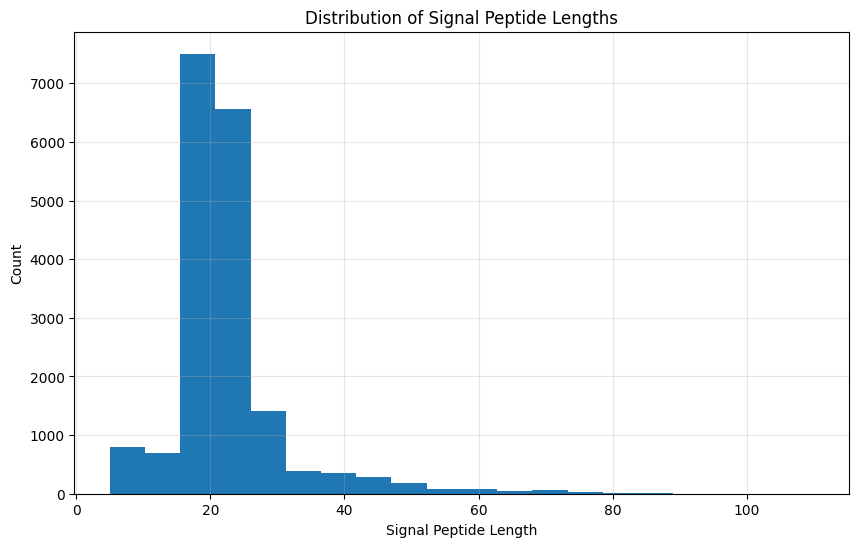

In [10]:
# For proteins with signal peptides, analyze the length distribution
signal_df = df[df['has_signal']].copy()
signal_df['signal_length'] = signal_df['signal_end'] - signal_df['signal_start'] + 1

print(f"Average signal peptide length: {signal_df['signal_length'].mean():.2f} amino acids")
print(f"Minimum signal peptide length: {signal_df['signal_length'].min()} amino acids")
print(f"Maximum signal peptide length: {signal_df['signal_length'].max()} amino acids")

# Plot the distribution of signal peptide lengths
if len(signal_df) > 0:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.hist(signal_df['signal_length'], bins=20)
    plt.xlabel('Signal Peptide Length')
    plt.ylabel('Count')
    plt.title('Distribution of Signal Peptide Lengths')
    plt.grid(True, alpha=0.3)
    plt.show()